In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import random as rand
import scipy
from scipy.optimize import fsolve
import os
from tqdm import tqdm
import sys
from scipy import special
from scipy import integrate
from scipy import stats
from colorsarr import colorsarr
from scipy import integrate
import pandas as pd
colarr = colorsarr()
carr = colarr.carr
cd = os.getcwd()
def smoothen(list, nm = 10):
    reslist = []
    meanlist = [k-nm//2 for k in range(nm)]
    for j in range(len(list)):
        reslist.append((sum([list[min(max(0,j+k),len(list)-1)] for k in meanlist]))/nm)
    return reslist

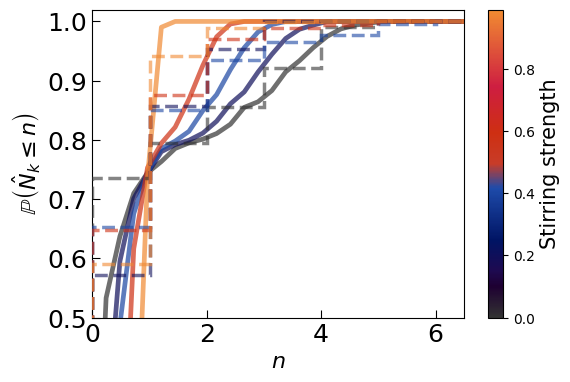

In [2]:
## Calibration from the distribution of N ##

nC = 8.E1
frac = 1.
def P(num, dataN, s):
    ## Read data ##
    n, sigN = frac, np.std(dataN)/np.mean(dataN)*frac #1., np.std(dataN)/np.mean(dataN) #np.mean(dataN), np.std(dataN)
    sn = s*n
    sigYN = s*sigN/np.sqrt(nC-1)
    ## Define bivariate variable ##
    def z(yN):
        return (yN - sn)**2/(sigYN**2)
    ## Histograms data ##
    hist_N, bins_N = np.histogram(np.array(dataN)*frac/np.mean(dataN), bins=800, density=True)
    hist_N = hist_N * np.diff(bins_N)
    
    ## joint proba for bivariate normal YN and YG##
    def gaussian_pdf(yN):
        """Gaussian probability density function"""
        exponent = - z(yN) / 2.
        return np.exp(exponent)/(np.sqrt( 2*np.pi ) * sigYN)

    ## Empirical CDF function from data ##
    def empirical_cdf(value, bins, probs):
        """Compute empirical CDF at a single value"""
        idx = np.searchsorted(bins, value, side='right') - 1
        idx = max(0, idx)
        return np.sum(probs[:idx])
    
    yNarr = np.linspace(sn-1.E2*sigYN, sn+1.E2*sigYN, int(1E4))
    #print((num-yNarr)/(1.-s), [gaussian_pdf(yN)*empirical_cdf((num-yN)/(1.-s), bins_N, hist_N) for yN in yNarr], alpha=0.3, c='blue')
    #ax.scatter((num-yNarr)/(1.-s), [empirical_cdf((num-yN)/(1.-s), bins_N, hist_N) for yN in yNarr], alpha=0.3, c='red')

    ## Compute integrand with x in [0., 0.5]##
    def integrand(yN, num):
        cdf_val = empirical_cdf((num-yN)/(1.-s), bins_N, hist_N)
        return cdf_val*gaussian_pdf(yN)
    
    ## Compute the CDF at point x ##
    integral = 0.
    if sigYN <= 1.E-3:
        integral = empirical_cdf(num, bins_N, hist_N)
    else:
        for i in range(len(yNarr)-1):
            integral += 0.5*(yNarr[i+1]-yNarr[i])*(integrand(yNarr[i], num) + integrand(yNarr[i+1], num))
    return integral

## Create figure ##
fig, ax = plt.subplots(figsize=(6,4))
ax.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6)
ax.set_xlim(0., 6.5)
ax.set_ylim(0.5, 1.02)
ax.set_xlabel(r'$n$', fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_ylabel(r'$\mathbb{P}\left(\hat{N}_k \leq n\right)$', fontsize=16)

## Read data ##
durlist = [6, 20, 60]
strenlist = ['2krpm', '5.2krpm', '16krpm', '30krpm']
timelist=[0,0,0,5,5,5]
numlist = np.linspace(0., 7., 30)
clist = carr.copy()
clist.reverse()
clist = [(0, clist[0]), (0.1, clist[1]), (0.15, clist[2]), (0.25, clist[3]), (0.42, clist[4]), (0.5, clist[10]),  (0.6, clist[11]), (0.75, clist[12]), (1., clist[13])] #[(i*1/11., clist[i]) for i in range(len(clist))]
cmapphase = LinearSegmentedColormap.from_list('cmap', clist)

N = nC
binrange = range(8)
rond = '0'
slist = [0.0, 0.2, 0.4, 0.6, 0.99] #[0.0, 0.2, 0.4, 0.6, 0.8, 0.99] #(np.linspace(0.1, .99, 6))

ref = '/251122/251122_original_R1_0h_0krpm.csv'
data = np.array(pd.read_csv(cd + ref, sep=","))
dataG = [dat[-11] for dat in data] + [data[-1][-10]+data[-1][-11]]
dataR = [dat[-10] for dat in data] + [data[-1][-10]+data[-1][-11]]
dataN = [(dat[-10] + dat[-11]) for dat in data]
n, bins, patches = ax.hist(np.array(dataN)*frac/np.mean(dataN), binrange, density=True, histtype="step",
                                cumulative=True, linewidth=2.5, color = cmapphase(0.), alpha=0.6, linestyle='--', label='Cdf after mixing', zorder=5)
## Plot final histogram ##
for k, stren in enumerate(strenlist):
    if rond == '0':
        rond2 = '1'
        reflist = ['/251122/251122_original_R1_0h_0krpm.csv', '/251122/251122_original_R'+rond2+'_5h_'+stren+'.csv']
    else:
        rond2 = '2'
        reflist = ['/251122/251122_original_R'+rond+'_5h_'+stren+'.csv', '/251122/251122_original_R'+rond2+'_5h_'+stren+'.csv']

    ## Plot final histogram ##
    ref = reflist[1]
    data = np.array(pd.read_csv(cd + ref, sep=","))
    dataG = [dat[-11] for dat in data] + [data[-1][-10]+data[-1][-11]]
    dataR = [dat[-10] for dat in data] + [data[-1][-10]+data[-1][-11]]
    dataN = [(dat[-10] + dat[-11]) for dat in data]
    n, bins, patches = ax.hist(np.array(dataN)*frac/np.mean(dataN), binrange, density=True, histtype="step",
                                    cumulative=True, linewidth=2.5, color = cmapphase(slist[k+1]), alpha=0.6, linestyle='--', label='Cdf after mixing', zorder=5)
compute = True
if compute:
    for s in slist:
        listname = cd + '/data/CDFN_s'+str(round(s,2))+'00krpmact'+'.npy'
        if os.path.exists(listname):
            ylist = np.load(listname)
        else:
            ylist = []
            for num in tqdm(numlist):
                ref = '/251122/251122_original_R1_0h_0krpm.csv'
                data = np.array(pd.read_csv(cd + ref, sep=","))
                dataG = [dat[-11] for dat in data] + [data[-1][-10]+data[-1][-11]]
                dataR = [dat[-10] for dat in data] + [data[-1][-10]+data[-1][-11]]
                dataN = [(dat[-10] + dat[-11]) for dat in data]
                #dataN = np.random.poisson(.5, size=int(1E6))
                ylist.append(P(num, dataN, s))
                np.save(listname, ylist)
        ylist = np.array([ylist[k] if ((ylist[k] >= ylist[k-1]) or k<1) else ylist[k-1] for k in range(len(ylist))])
        ax.plot(numlist, ylist, alpha = 0.7, lw=3.4, c = cmapphase(s))
norm = mpl.colors.Normalize(vmin=slist[0], vmax=slist[-1])
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmapphase), ax=ax, label='s')
cbar.set_label('Stirring strength', fontsize=15)
fig.savefig('cpfN_stirring_vs_data_diffstrengths'+rond+'_act.pdf')

/home/barnabe/Documents/Github/These/projets/compartments/exp_ryo/data/CDFabs_stirring_sep_s0.1_N80.0_frac1.0_round1.npy
/home/barnabe/Documents/Github/These/projets/compartments/exp_ryo/data/CDFabs_stirring_sep_s0.2_N80.0_frac1.0_round1.npy
/home/barnabe/Documents/Github/These/projets/compartments/exp_ryo/data/CDFabs_stirring_sep_s0.5_N80.0_frac1.0_round1.npy
/home/barnabe/Documents/Github/These/projets/compartments/exp_ryo/data/CDFabs_stirring_sep_s0.95_N80.0_frac1.0_round1.npy


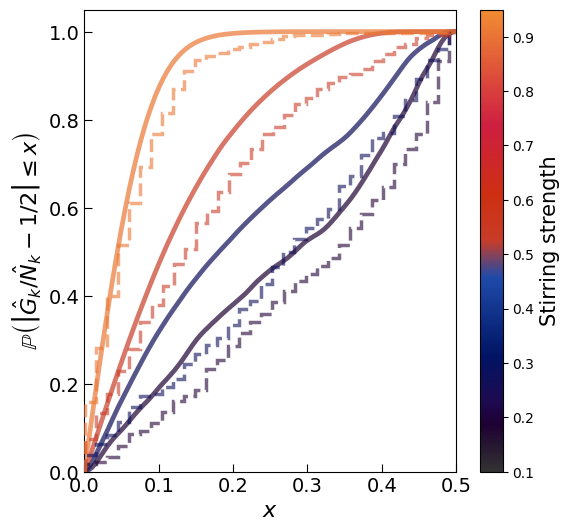

In [3]:
## Compute updated distrib of abs(hatx - 1/2) ##
n=1
nC = 8.E1
frac = 1.
def P(x, dataN, dataG, s):
    ## Read data ##
    n, g, sigN, sigG = frac, np.mean(dataG)*frac/np.mean(dataN), np.std(dataN)*frac/np.mean(dataN), np.std(dataG)*frac/np.mean(dataN)
    sn, sg = s*n, s*g
    sigYN, sigYG = s*sigN/np.sqrt(nC-1), s*sigG/np.sqrt(nC-1)
    covNG = np.cov(np.array(dataG)*frac/np.mean(dataN), np.array(dataN)*frac/np.mean(dataN), ddof=1)[0, 1]
    covYNG = s**2 * covNG/(nC-1)
    rho = covYNG/(sigYN*sigYG)
    ## Define bivariate variable ##
    def z(yN, yG):
        return (yN - sn)**2/(sigYN**2) + 2.*rho*(yN - sn)*(yG - sg)/(sigYN*sigYG) + (yG - sg)**2/(sigYG**2)
    ## Histograms data ##
    hist_G, bins_G = np.histogram(np.array(dataG)*frac/np.mean(dataN), bins=800, density=True)
    hist_G = hist_G * np.diff(bins_G)
    hist_N, bins_N = np.histogram(np.array(dataN)*frac/np.mean(dataN), bins=800, density=True)
    hist_N = hist_N * np.diff(bins_N)
    
    ## joint proba for bivariate normal YN and YG##
    def gaussian_pdf(yN, yG):
        """Gaussian probability density function"""
        exponent = - z(yN, yG) / (2*(1 - rho**2))
        return np.exp(exponent)/(2*np.pi * sigYG * sigYN * np.sqrt(1 - rho**2))

    ## Empirical CDF function from data ##
    def empirical_cdf(value, bins, probs):
        """Compute empirical CDF at a single value"""
        idx = np.searchsorted(bins, value, side='right') - 1
        idx = max(0, idx)
        return np.sum(probs[:idx])

    ## Compute integrand with x in [0., 0.5]##
    def integrand(yN, yG, x):
        ## Histogram of abs(Gk +yG/(1-s) - 0.5(Nk+yN/(1-s))) - xNk##
        data_comb = np.abs(np.array(dataG)/np.mean(dataN) + yG/(1.-s) - 0.5*(np.array(dataN)/np.mean(dataN)+yN/(1.-s))) - x*np.array(dataN)/np.mean(dataN)
        hist_comb, bins_comb = np.histogram(data_comb, bins=800, density=True)
        hist_comb = hist_comb * np.diff(bins_comb)
        cdf_val = empirical_cdf(x*yN/(1.-s), bins_comb, hist_comb)
        return gaussian_pdf(yN, yG)*cdf_val
    
    ## Compute the CDF at point x ##
    integral = scipy.integrate.dblquad(lambda yG, yN: integrand(yN, yG, x), sn - 2E1*sigYN, sn + 2E1*sigYN, lambda yN: sg - 2E1*sigYG, lambda yN: sg + 2E1*sigYG, epsabs=1.0e-1, epsrel=1.0e-1)[0]
    return integral

## Create figure ##
fig, ax = plt.subplots(figsize=(6,6))
ax.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6)
ax.set_xlim(0., 0.5)
ax.set_ylim(0., 1.05)
ax.set_xlabel(r'$x$', fontsize=16)
ax.set_ylabel(r'$\mathbb{P}\left(\left| \hat{G}_k/\hat{N}_k - 1/2 \right|\leq x\right)$', fontsize=16)

## Read data ##
durlist = [6, 20, 60]
strenlist = ['0krpm', '2krpm', '5.2krpm', '16krpm', '30krpm']
timelist=[0,0,0,5,5,5]
xlist = np.linspace(0., .5, 40)
clist = carr.copy()
clist.reverse()
clist = [(0, clist[0]), (0.1, clist[1]), (0.15, clist[2]), (0.25, clist[3]), (0.42, clist[4]), (0.5, clist[10]),  (0.6, clist[11]), (0.75, clist[12]), (1., clist[13])] #[(i*1/11., clist[i]) for i in range(len(clist))]
cmapphase = LinearSegmentedColormap.from_list('cmap', clist)

N = nC
rond = '1'
slist = [0.04, 0.1, 0.2, 0.5, 0.95]
if rond == '0':
    ref = '/251122/251122_original_R1_0h_0krpm.csv'
    data = np.array(pd.read_csv(cd + ref, sep=","))
    dataG = np.array([dat[-11] for dat in data] + [data[-1][-10]+data[-1][-11]])
    dataR = np.array([dat[-10] for dat in data] + [data[-1][-10]+data[-1][-11]])
    dataN = np.array([(dat[-10] + dat[-11]) for dat in data] + [data[-1][-10]+data[-1][-11]])
    data_abs = np.concatenate((np.abs(np.array(dataG)/np.array(dataN) - 0.5), np.array([0.52])))
    n, bins, patches = ax.hist(data_abs, 35, density=True, histtype="step",
                                    cumulative=True, linewidth=2.5, color = cmapphase(slist[0]), alpha=0.6, linestyle='--', label='Cdf after mixing', zorder=5)

for k, stren in enumerate(strenlist[1:]):
    if rond == '0':
        rond2 = '1'
        reflist = ['/251122/251122_original_R1_0h_0krpm.csv', '/251122/251122_original_R'+rond2+'_5h_'+stren+'.csv']
    else:
        rond2 = '2'
        reflist = ['/251122/251122_original_R'+rond+'_5h_'+stren+'.csv', '/251122/251122_original_R'+rond2+'_5h_'+stren+'.csv']

    ## Plot final histogram ##
    ref = reflist[1]
    data = np.array(pd.read_csv(cd + ref, sep=","))
    dataG = [dat[-11] for dat in data] + [data[-1][-10]+data[-1][-11]]
    dataR = [dat[-10] for dat in data] + [data[-1][-10]+data[-1][-11]]
    dataN = [(dat[-10] + dat[-11]) for dat in data] + [data[-1][-10]+data[-1][-11]]
    data_abs = np.concatenate((np.abs(np.array(dataG)/np.array(dataN) - 0.5), np.array([0.52])))
    n, bins, patches = ax.hist(data_abs, 35, density=True, histtype="step",
                                    cumulative=True, linewidth=2.5, color = cmapphase(slist[k+1]), alpha=0.6, linestyle='--', label='Cdf after mixing', zorder=5)

if rond== '1':
    slist = slist[1:]
    
for i, s in enumerate(slist):
    listname = cd + '/data/CDFabs_stirring_sep_s'+str(round(s,2))+'_N'+str(round(N,2))+'_frac'+str(round(frac,2))+'_round'+rond+'.npy'
    if rond != '0': #If second round then compute from initial distrib
        print(listname)
        if os.path.exists(listname):
            ylist = np.load(listname)
        else:
            ylist = []
            for x in tqdm(xlist):
                ref = reflist[0]
                data = np.array(pd.read_csv(cd + ref, sep=","))
                dataG = np.array([dat[-11] for dat in data] + [data[-1][-10]+data[-1][-11]])
                dataR = np.array([dat[-10] for dat in data] + [data[-1][-10]+data[-1][-11]])
                dataN = np.array([(dat[-10] + dat[-11]) for dat in data] + [data[-1][-10]+data[-1][-11]])
                ylist.append(P(x, dataN, dataG, s))
        np.save(listname, ylist)
    else: #Otherwise compute from perfectly bimodal
        filename = cd + '/data/CDFabs_stirring_sep_s'+str(round(s,2))+'_N'+str(round(N,2))+'_frac'+str(round(frac,2))+'_round'+rond+'.npy'
        ylist = np.load(filename)
    ylist = np.array([ylist[k] if ((ylist[k] >= ylist[k-1]) or k<1) else ylist[k-1] for k in range(len(ylist))])
    ax.plot(np.linspace(0., 0.5, len(ylist)), smoothen(ylist, nm=3), alpha = 0.7, lw=3.4, c = cmapphase(s))
norm = mpl.colors.Normalize(vmin=slist[0], vmax=slist[-1])
cbar = fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmapphase), ax=ax, label='s')
cbar.set_label('Stirring strength', fontsize=15)
fig.savefig('cpf_stirring_vs_data_diffstrengths'+rond+'_act.pdf')

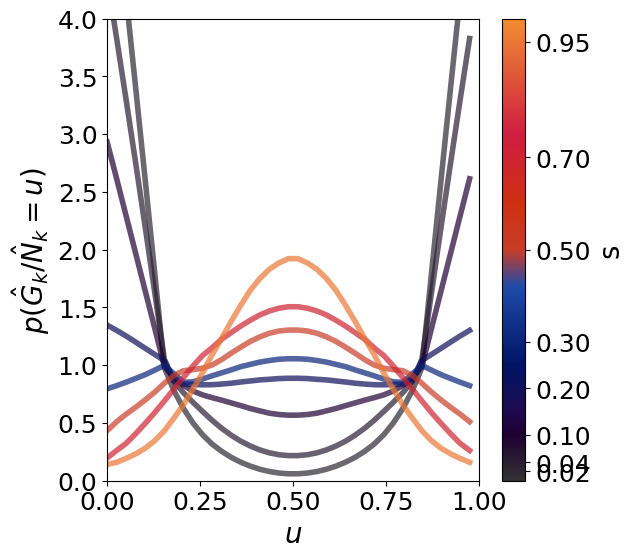

In [4]:
## With N stochastic ##
ulist = np.linspace(0., 1., 40)
frac = 1.
N = 8.E1

fig1 = plt.figure(figsize=(6,6)) 
ax1 = fig1.add_subplot(111)

cdf = False
cdfabs = False

def symetrize(arr):
    res = []
    for i, val in enumerate(arr):
        res.append((arr[i] + arr[-1-i])/2.)
    return np.array(res)

#Initial distrib of N/<N>
ref = '/251122/251122_original_R1_0h_0krpm.csv'
data = np.array(pd.read_csv(cd + ref, sep=","))
dataG = np.array([dat[-11] for dat in data] + [data[-1][-10]+data[-1][-11]])
dataR = np.array([dat[-10] for dat in data] + [data[-1][-10]+data[-1][-11]])
dataN = np.array([(dat[-10] + dat[-11]) for dat in data] + [data[-1][-10]+data[-1][-11]])

n = frac
g=frac/2.
sigmaN = np.std(dataN)/np.mean(dataN) * frac
sigmaG = np.sqrt(np.std(dataN)**2/2. + np.mean(dataN)**2/4.)/np.mean(dataN) * frac
clist = carr.copy()
clist.reverse()
clist = [(0, clist[0]), (0.1, clist[1]), (0.15, clist[2]), (0.25, clist[3]), (0.42, clist[4]), (0.5, clist[10]),  (0.6, clist[11]), (0.75, clist[12]), (1., clist[13])]  #[(i*1/11., clist[i]) for i in range(len(clist))]
cmapphase = LinearSegmentedColormap.from_list('cmap', clist)

def cdfG(y, x, s, n):
        #return (1+scipy.stats.poisson.cdf(y/(1-x)/(1-s))-scipy.stats.poisson.cdf(-y/x/(1-s)))/2
        #return sum([scipy.stats.poisson.pmf(nu, n) *(int(x*nu+y/(1-s)>0) + int((x-1)*nu + y/(1-s)>0))/2. for nu in range(100)])
        return (1.+scipy.stats.poisson.cdf(y/(1-x)/(1-s),n)-scipy.stats.poisson.cdf(-y/x/(1-s),n))/2

## Empirical CDF function from data ##
def empirical_cdf(value, bins, probs):
    """Compute empirical CDF at a single value"""
    idx = np.searchsorted(bins, value, side='right') - 1
    idx = max(0, idx)
    return np.sum(probs[:idx])

def cdfGcomb(yN, yG, u, s):
        datacomb1 = yG / ((1.-s)*dataN/np.mean(dataN) + yN)
        datacomb2 = ((1.-s)*dataN/np.mean(dataN) + yG ) / ((1.-s)*dataN/np.mean(dataN) + yN)
        hist_comb1, bins_comb1 = np.histogram(datacomb1, bins=200, density=True)
        hist_comb1 = hist_comb1 * np.diff(bins_comb1)
        hist_comb2, bins_comb2 = np.histogram(datacomb2, bins=200, density=True)
        hist_comb2 = hist_comb2 * np.diff(bins_comb2)
        combG = 0.5*empirical_cdf(u, bins_comb1, hist_comb1) + 0.5*empirical_cdf(u, bins_comb2, hist_comb2) #cdfGcomb(yN, yG, x, s, n)        
        return combG

def CDF(x, s, n):
    sigma = np.sqrt( s**2 * n / (N-1) * (x**2+(n/4+1/2)-x) )
    mean = s*n*(x - 1/2)
    integ = integrate.quad(lambda y: np.exp(-(y - mean)**2/(2*sigma**2))*cdfG(y, x, s, n)/(np.sqrt(2*np.pi*sigma**2)), -np.inf, np.inf)[0]
    return integ

def CDFinteg(yG, yN, x, s):
    datacomb1 = np.abs(yG / ((1.-s)*dataN/np.mean(dataN) + yN) - 0.5)
    datacomb2 = np.abs(((1.-s)*dataN/np.mean(dataN) + yG ) / ((1.-s)*dataN/np.mean(dataN) + yN) - 0.5)
    hist_comb1, bins_comb1 = np.histogram(datacomb1, bins=200, density=True)
    hist_comb1 = hist_comb1 * np.diff(bins_comb1)
    hist_comb2, bins_comb2 = np.histogram(datacomb2, bins=200, density=True)
    hist_comb2 = hist_comb2 * np.diff(bins_comb2)
    combG = 0.5*empirical_cdf(x, bins_comb1, hist_comb1) + 0.5*empirical_cdf(x, bins_comb2, hist_comb2) #cdfGcomb(yN, yG, x, s, n)        
    return combG

def CDFabs(x, s, n): #Cumulative proba of |^G_k/^N_k - 1/2|#
    sigYN, sigYG = sigmaN * s/np.sqrt(N-1), sigmaG * s/np.sqrt(N-1)
    sn, sg = s*n, s*n/2
    rho = np.sqrt(1./2. + (n/sigmaN/2.)**2)
    def z(yN, yG):
        return (yN - sn)**2/(sigYN**2) + 2.*rho*(yN - sn)*(yG - sg)/(sigYN*sigYG) + (yG - sg)**2/(sigYG**2)
    def gaussian_pdf(yN, yG):
        """Gaussian probability density function"""
        exponent = - z(yN, yG) / (2*(1 - rho**2))
        return np.exp(exponent)/(2*np.pi * sigYG * sigYN * np.sqrt(1 - rho**2))
    integ = 0.
    yNlist = np.linspace(sn - 2.5E1*sigYN, sn + 2.5E1*sigYN, int(1.4E2))
    yGlist = np.linspace(sg - 2.5E1*sigYG, sg + 2.5E1*sigYG, int(1.4E2))
    for yN in yNlist:
        for yG in yGlist:
            res = CDFinteg(yG, yN, x, s) * (yNlist[1]-yNlist[0])*(yGlist[1]-yGlist[0]) * gaussian_pdf(yN, yG)
            integ += res
    return integ

def P(u, s): #Cumulative proba of the updated fraction ^G_k/^N_k#
    ## Read data ##
    sigYN, sigYG = sigmaN * s/np.sqrt(N-1), sigmaG * s/np.sqrt(N-1)
    sn, sg = s*n, s*n/2
    rho = np.sqrt(1./2. + (n/sigmaN/2.)**2)
    def z(yN, yG):
        return (yN - sn)**2/(sigYN**2) + 2.*rho*(yN - sn)*(yG - sg)/(sigYN*sigYG) + (yG - sg)**2/(sigYG**2)
    def gaussian_pdf(yN, yG):
        """Gaussian probability density function"""
        exponent = - z(yN, yG) / (2*(1 - rho**2))
        return np.exp(exponent)/(2*np.pi * sigYG * sigYN * np.sqrt(1 - rho**2))
    ## Compute integrand with x in [0., 0.5]##
    def integrand(yN, yG, u):
        return gaussian_pdf(yN, yG)*cdfGcomb(yN, yG, u, s)
    
    ## Compute the CDF at point x ##
    integral = scipy.integrate.dblquad(lambda yG, yN: integrand(yN, yG, u), sn - 2E1*sigYN, sn + 2E1*sigYN, lambda yN: sg - 2E1*sigYG, lambda yN: sg + 2E1*sigYG, epsabs=1.0e-1, epsrel=1.0e-1)[0]
    return integral

rond = '0'
slist = [0.02, 0.04, 0.1, 0.2, 0.3, 0.5, 0.7, 0.95] #[0.05, 0.2, 0.35, 0.43, 0.55, 0.6, 0.7, 0.99] #np.concatenate((np.array([0.01]), np.linspace(0.01, .95, 6)[1:]))
ax1.set_xlabel(r'$u$', fontsize=20)
for s in slist:
    if cdf:
        CDFlist = [P(u,s) for u in ulist]
        dlist = [(CDFlist[i+1]-CDFlist[i])/(ulist[i+1]-ulist[i]) for i in range(len(CDFlist)-1)]
        dlist = smoothen(dlist)
        ax1.plot(ulist, CDFlist, label=r'$p(x|s={})$'.format(s), alpha = 0.7, lw=4., c = cmapphase(s))
    elif cdfabs:
        xlist = np.linspace(0., .5-1E-10, 40)
        filename = cd + '/data/CDFabs_stirring_sep_s'+str(round(s,2))+'_N'+str(round(N,2))+'_frac'+str(round(frac,2))+'_round'+rond+'.npy'
        if os.path.exists(filename):
            CDFabslist = np.load(filename)
        else:
            CDFabslist = []
            for x in tqdm(xlist):
                CDFabslist.append(CDFabs(x,s,n))
        CDFabslist = np.array([CDFabslist[k] if ((CDFabslist[k] >= CDFabslist[k-1]) or k<1) else CDFabslist[k-1] for k in range(len(CDFabslist))])
        ax1.plot(xlist, smoothen(CDFabslist, nm=3), alpha = 0.7, lw=4., c = cmapphase(s))
        ax1.set_xlabel(r'$x$', fontsize=20)   
        np.save(filename, CDFabslist)
    else:
        filename = cd + '/data/dp_stirring_sep_s'+str(round(s,2))+'_N'+str(round(N,2))+'_frac'+str(round(frac,2))+'_round'+rond+'.npy'
        if os.path.exists(filename):
            dlist = np.load(filename)
        else:
            CDFlist = []
            for u in tqdm(ulist):
                CDFlist.append(P(u,s))
                dlist = np.array([(CDFlist[i+1]-CDFlist[i])/(ulist[i+1]-ulist[i]) for i in range(len(CDFlist)-1)])
                np.save(cd + '/data/dp_stirring_sep_s'+str(round(s,2))+'_N'+str(round(N,2))+'_frac'+str(round(frac,2))+'_round'+rond+'.npy', dlist)
        ax1.plot(ulist[:-1], smoothen(symetrize(dlist)), alpha = 0.7, lw=4., c = cmapphase(s))
cbar = fig1.colorbar(plt.cm.ScalarMappable(cmap=cmapphase), ax=ax1, ticks=slist, label='s')
cbar.set_label('s', fontsize=20)
cbar.ax.tick_params(labelsize=18)
ax1.set_xlim(0.,1.05)
ax1.tick_params(axis='both', which='major', labelsize=18)
if cdf:
    ax1.set_ylabel(r'$P\left(\frac{\tilde{G}_k}{\tilde{N}_k}<u\right)$', fontsize=23)
    fig1.savefig('distrib_stirring_sep_cdf.pdf')
elif cdfabs:
    ax1.set_xlim(0., 0.5)
    ax1.set_ylim(0., 1.05)
    ax1.set_ylabel(r'$\mathbb{P}\left(\left| \hat{G}_k/\hat{N}_k - 1/2 \right|\leq x\right)$', fontsize=18)
    fig1.savefig('distrib_stirring_sep_cdfabs.pdf')
else:
    ax1.set_xlim(0., 1.)
    ax1.set_ylim(0., 4.)
    ax1.set_ylabel(r'$p(\hat{G}_k/\hat{N}_k = u)$', fontsize=20)
    fig1.savefig('distrib_stirring_sep.pdf')

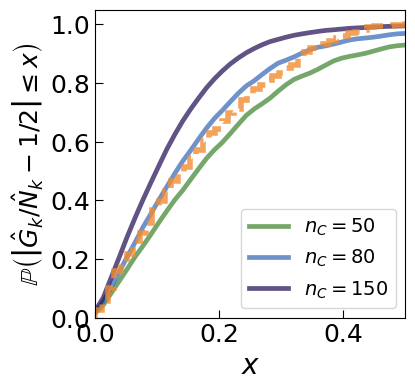

In [5]:
frac = 1.

#Initial distrib of N/<N>
ref = '/251122/251122_original_R1_0h_0krpm.csv'
data = np.array(pd.read_csv(cd + ref, sep=","))
dataG = np.array([dat[-11] for dat in data] + [data[-1][-10]+data[-1][-11]])
dataR = np.array([dat[-10] for dat in data] + [data[-1][-10]+data[-1][-11]])
dataN = np.array([(dat[-10] + dat[-11]) for dat in data] + [data[-1][-10]+data[-1][-11]])

n = frac
g=frac/2.
sigmaN = np.std(dataN)/np.mean(dataN) * frac
sigmaG = np.sqrt(np.std(dataN)**2/2. + np.mean(dataN)**2/4.)/np.mean(dataN) * frac
clist = carr.copy()
clist.reverse()
clist = [(0, clist[0]), (0.1, clist[1]), (0.15, clist[2]), (0.25, clist[3]), (0.42, clist[4]), (0.5, clist[10]),  (0.6, clist[11]), (0.75, clist[12]), (1., clist[13])]  #[(i*1/11., clist[i]) for i in range(len(clist))]
cmapphase = LinearSegmentedColormap.from_list('cmap', clist)

def cdfG(y, x, s, n):
        #return (1+scipy.stats.poisson.cdf(y/(1-x)/(1-s))-scipy.stats.poisson.cdf(-y/x/(1-s)))/2
        #return sum([scipy.stats.poisson.pmf(nu, n) *(int(x*nu+y/(1-s)>0) + int((x-1)*nu + y/(1-s)>0))/2. for nu in range(100)])
        return (1.+scipy.stats.poisson.cdf(y/(1-x)/(1-s),n)-scipy.stats.poisson.cdf(-y/x/(1-s),n))/2

## Empirical CDF function from data ##
def empirical_cdf(value, bins, probs):
    """Compute empirical CDF at a single value"""
    idx = np.searchsorted(bins, value, side='right') - 1
    idx = max(0, idx)
    return np.sum(probs[:idx])

def cdfGcomb(yN, yG, u, s):
        datacomb1 = yG / ((1.-s)*dataN/np.mean(dataN) + yN)
        datacomb2 = ((1.-s)*dataN/np.mean(dataN) + yG ) / ((1.-s)*dataN/np.mean(dataN) + yN)
        hist_comb1, bins_comb1 = np.histogram(datacomb1, bins=200, density=True)
        hist_comb1 = hist_comb1 * np.diff(bins_comb1)
        hist_comb2, bins_comb2 = np.histogram(datacomb2, bins=200, density=True)
        hist_comb2 = hist_comb2 * np.diff(bins_comb2)
        combG = 0.5*empirical_cdf(u, bins_comb1, hist_comb1) + 0.5*empirical_cdf(u, bins_comb2, hist_comb2) #cdfGcomb(yN, yG, x, s, n)        
        return combG

def CDF(x, s, n):
    sigma = np.sqrt( s**2 * n / (N-1) * (x**2+(n/4+1/2)-x) )
    mean = s*n*(x - 1/2)
    integ = integrate.quad(lambda y: np.exp(-(y - mean)**2/(2*sigma**2))*cdfG(y, x, s, n)/(np.sqrt(2*np.pi*sigma**2)), -np.inf, np.inf)[0]
    return integ

def CDFinteg(yG, yN, x, s):
    datacomb1 = np.abs(yG / ((1.-s)*dataN/np.mean(dataN) + yN) - 0.5)
    datacomb2 = np.abs(((1.-s)*dataN/np.mean(dataN) + yG ) / ((1.-s)*dataN/np.mean(dataN) + yN) - 0.5)
    hist_comb1, bins_comb1 = np.histogram(datacomb1, bins=200, density=True)
    hist_comb1 = hist_comb1 * np.diff(bins_comb1)
    hist_comb2, bins_comb2 = np.histogram(datacomb2, bins=200, density=True)
    hist_comb2 = hist_comb2 * np.diff(bins_comb2)
    combG = 0.5*empirical_cdf(x, bins_comb1, hist_comb1) + 0.5*empirical_cdf(x, bins_comb2, hist_comb2) #cdfGcomb(yN, yG, x, s, n)        
    return combG

def CDFabs(x, s, n):
    sigYN, sigYG = sigmaN * s/np.sqrt(N-1), sigmaG * s/np.sqrt(N-1)
    sn, sg = s*n, s*n/2
    rho = np.sqrt(1./2. + (n/sigmaN/2.)**2)
    def z(yN, yG):
        return (yN - sn)**2/(sigYN**2) + 2.*rho*(yN - sn)*(yG - sg)/(sigYN*sigYG) + (yG - sg)**2/(sigYG**2)
    def gaussian_pdf(yN, yG):
        """Gaussian probability density function"""
        exponent = - z(yN, yG) / (2*(1 - rho**2))
        return np.exp(exponent)/(2*np.pi * sigYG * sigYN * np.sqrt(1 - rho**2))
    integ = 0.
    yNlist = np.linspace(sn - 2.5E1*sigYN, sn + 2.5E1*sigYN, int(1.4E2))
    yGlist = np.linspace(sg - 2.5E1*sigYG, sg + 2.5E1*sigYG, int(1.4E2))
    for yN in yNlist:
        for yG in yGlist:
            res = CDFinteg(yG, yN, x, s) * (yNlist[1]-yNlist[0])*(yGlist[1]-yGlist[0]) * gaussian_pdf(yN, yG)
            integ += res
    return integ

def P(u, s):
    ## Read data ##
    sigYN, sigYG = sigmaN * s/np.sqrt(N-1), sigmaG * s/np.sqrt(N-1)
    sn, sg = s*n, s*n/2
    rho = np.sqrt(1./2. + (n/sigmaN/2.)**2)
    def z(yN, yG):
        return (yN - sn)**2/(sigYN**2) + 2.*rho*(yN - sn)*(yG - sg)/(sigYN*sigYG) + (yG - sg)**2/(sigYG**2)
    def gaussian_pdf(yN, yG):
        """Gaussian probability density function"""
        exponent = - z(yN, yG) / (2*(1 - rho**2))
        return np.exp(exponent)/(2*np.pi * sigYG * sigYN * np.sqrt(1 - rho**2))
    ## Compute integrand with x in [0., 0.5]##
    def integrand(yN, yG, u):
        return gaussian_pdf(yN, yG)*cdfGcomb(yN, yG, u, s)
    
    ## Compute the CDF at point x ##
    integral = scipy.integrate.dblquad(lambda yG, yN: integrand(yN, yG, u), sn - 2E1*sigYN, sn + 2E1*sigYN, lambda yN: sg - 2E1*sigYG, lambda yN: sg + 2E1*sigYG, epsabs=1.0e-1, epsrel=1.0e-1)[0]
    return integral


slist = (np.linspace(0.1, .99, 6))

fig, ax = plt.subplots(figsize=(4,4))
ax.tick_params(axis='both', which='major', labelsize=14, direction='in', length=6)
ax.set_xlim(0., 0.5)
ax.set_ylim(0., 1.05)
ax.set_xlabel(r'$x$', fontsize=16)
ax.set_ylabel(r'$\mathbb{P}\left(\left| \hat{G}_k/\hat{N}_k - 1/2 \right|\leq x\right)$', fontsize=16)

## Read data ##
xlist = np.linspace(0., .5, 40)
clist = carr.copy()
clist.reverse()
clist = [(0, clist[0]), (0.18, clist[1]), (0.25, clist[2]), (0.38, clist[3]), (0.5, clist[4]), (0.6, clist[10]),  (0.7, clist[11]), (0.82, clist[12]), (1., clist[13])] #[(i*1/11., clist[i]) for i in range(len(clist))]
cmapphase = LinearSegmentedColormap.from_list('cmap', clist)

slist = [0.95]
for s in slist:
    Nlist = [5E1, 8E1, 1.5E2]
    for i, N in enumerate(Nlist):
        ylist = []
        filename = cd + '/data/CDFabs_stirring_sep_s'+str(round(s,2))+'_N'+str(round(N,2))+'_frac'+str(round(frac,2))+'_round'+rond+'.npy'
        if os.path.exists(filename):
            CDFabslist = np.load(filename)
        else:
            CDFabslist = []
            for x in tqdm(xlist):
                CDFabslist.append(CDFabs(x,s,n))
        ylist = CDFabslist
        ylist = np.array([ylist[k] if ((ylist[k] >= ylist[k-1]) or k<1) else ylist[k-1] for k in range(len(ylist))])
        ax.plot(xlist, smoothen(ylist, nm=3), alpha = 0.7, lw=3.4, c = carr[int(3*i+6)], label=r'$n_C={}$'.format(int(N)))
        np.save(filename, CDFabslist)

ref = '/251122/251122_original_R1_5h_30krpm.csv'
data = np.array(pd.read_csv(cd + ref, sep=","))
dataG = np.array([dat[-11] for dat in data] + [data[-1][-10]+data[-1][-11]])
dataR = np.array([dat[-10] for dat in data] + [data[-1][-10]+data[-1][-11]])
dataN = np.array([(dat[-10] + dat[-11]) for dat in data] + [data[-1][-10]+data[-1][-11]])
n, bins, patches = ax.hist(np.concatenate((np.abs(np.array(dataG)/np.array(dataN) - 0.5), np.array([0.51]))), 50, density=True, histtype="step",
                                cumulative=True, linewidth=4., color = carr[1], alpha=0.8, linestyle='--')

ax.set_xlabel(r'$x$', fontsize=20)
ax.legend(fontsize=14)
ax.set_xlim(0.,1.05)
ax.tick_params(axis='both', which='major', labelsize=18)
ax.set_xlim(0., 0.5)
ax.set_ylim(0., 1.05)
ax.set_ylabel(r'$\mathbb{P}\left(\left| \hat{G}_k/\hat{N}_k - 1/2 \right|\leq x\right)$', fontsize=18)
fig.savefig(cd + '/calibration_N.pdf')